# Event classification for payment card fraud detection

**Author:** [achoum](https://github.com/achoum/)<br>
**Date created:** 2024/02/01<br>
**Last modified:** 2024/02/01<br>
**Description:** Detection of fraudulent payment card transactions using Temporian and a feed-forward neural network.

In [ ]:
# Run this cell once to install the necessary packages.
# After it finishes, please restart the Colab runtime (Runtime -> Restart runtime).
# Then, you can run this cell again to proceed with the imports.
!pip install keras keras_tuner pandas tf-nightly tensorboard scikit-learn

import numpy as np
import os
import pandas as pd
import datetime
import math
import tensorflow as tf
from sklearn.metrics import RocCurveDisplay
import keras  # To train the Machine Learning model
import keras_tuner  # To find the best hyperparameters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.7/630.7 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 150.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 144.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 167.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 25.8 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## Introduction

Payment fraud detection is critical for banks, businesses, and consumers. In
Europe alone, fraudulent transactions were estimated at
[€1.89 billion in 2019](https://www.ecb.europa.eu/pub/pdf/cardfraud/ecb.cardfraudreport202110~cac4c418e8.en.pdf).
Worldwide, approximately
[3.6%](https://www.cybersource.com/content/dam/documents/campaign/fraud-report/global-fraud-report-2022.pdf)
of commerce revenue is lost to fraud. In this notebook, we train and evaluate a
model to detect fraudulent transactions using the synthetic dataset attached to
the book
[Reproducible Machine Learning for Credit Card Fraud Detection](https://fraud-detection-handbook.github.io/fraud-detection-handbook/Foreword.html)
by Le Borgne et al.

Fraudulent transactions often cannot be detected by looking at transactions in
isolation. Instead, fraudulent transactions are detected by looking at patterns
across multiple transactions from the same user, to the same merchant, or with
other types of relationships. To express these relationships in a way that is
understandable by a machine learning model, and to augment features with feature
 engineering, we We use the
 [Temporian](https://temporian.readthedocs.io/en/latest) preprocessing library.

We preprocess a transaction dataset into a tabular dataset and use a
feed-forward neural network to learn the patterns of fraud and make predictions.

## Loading the dataset

The dataset contains payment transactions sampled between April 1, 2018 and
September 30, 2018. The transactions are stored in CSV files, one for each day.

**Note:** Downloading the dataset takes ~1 minute.

In [ ]:
start_date = datetime.date(2018, 4, 1)
end_date = datetime.date(2018, 9, 30)

# Load the dataset as a Pandas dataframe.
cache_path = "fraud_detection_cache.csv"
if not os.path.exists(cache_path):
    print("Download dataset")
    dataframes = []
    num_files = (end_date - start_date).days
    counter = 0
    while start_date <= end_date:
        if counter % (num_files // 10) == 0:
            print(f"[{100 * (counter+1) // num_files}%]", end="", flush=True)
        print(".", end="", flush=True)
        url = f"https://github.com/Fraud-Detection-Handbook/simulated-data-raw/raw/6e67dbd0a3bfe0d7ec33abc4bce5f37cd4ff0d6a/data/{start_date}.pkl"
        dataframes.append(pd.read_pickle(url))
        start_date += datetime.timedelta(days=1)
        counter += 1
    print("done", flush=True)
    transactions_dataframe = pd.concat(dataframes)
    transactions_dataframe.to_csv(cache_path, index=False)
else:
    print("Load dataset from cache")
    transactions_dataframe = pd.read_csv(
        cache_path, dtype={"CUSTOMER_ID": bytes, "TERMINAL_ID": bytes}
    )

print(f"Found {len(transactions_dataframe)} transactions")

Download dataset
[0%]..................[10%]..................[20%]..................[30%]..................[40%]..................[50%]..................[59%]..................[69%]..................[79%]..................[89%]..................[99%]...done
Found 1754155 transactions


Each transaction is represented by a single row, with the following columns of
interest:

- **TX_DATETIME**: The date and time of the transaction.
- **CUSTOMER_ID**: The unique identifier of the customer.
- **TERMINAL_ID**: The identifier of the terminal where the transaction was
    made.
- **TX_AMOUNT**: The amount of the transaction.
- **TX_FRAUD**: Whether the transaction is fraudulent (1) or not (0).

In [ ]:
transactions_dataframe = transactions_dataframe[
    ["TX_DATETIME", "CUSTOMER_ID", "TERMINAL_ID", "TX_AMOUNT", "TX_FRAUD"]
]

transactions_dataframe.head(4)

,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD
0,2018-04-01 00:00:31,596,3156,57.16,0
1,2018-04-01 00:02:10,4961,3412,81.51,0
2,2018-04-01 00:07:56,2,1365,146.00,0
3,2018-04-01 00:09:29,4128,8737,64.49,0


The dataset is highly imbalanced, with the majority of transactions being
legitimate.

In [ ]:
fraudulent_rate = transactions_dataframe["TX_FRAUD"].mean()
print("Rate of fraudulent transactions:", fraudulent_rate)

Rate of fraudulent transactions: 0.008369271814634397


The
[pandas dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)
is converted into a
[Temporian EventSet](https://temporian.readthedocs.io/en/latest/reference/temporian/EventSet/),
which is better suited for the data exploration and feature preprocessing of the
 next steps.

In [ ]:
# Convert to Pandas datetime and set as index for rolling operations
df = transactions_dataframe.copy()
df['TX_DATETIME'] = pd.to_datetime(df['TX_DATETIME'])
df.set_index('TX_DATETIME', inplace=True)
df.sort_index(inplace=True)

df.head()

,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD
TX_DATETIME,,,,
2018-04-01 00:00:31,596,3156,57.16,0
2018-04-01 00:02:10,4961,3412,81.51,0
2018-04-01 00:07:56,2,1365,146.00,0
2018-04-01 00:09:29,4128,8737,64.49,0
2018-04-01 00:10:34,927,9906,50.99,0


It is possible to plot the entire dataset, but the resulting plot will be
difficult to read. Instead, we can group the transactions per client.

<Axes: title={'center': 'Customer 3774 Transactions'}, xlabel='TX_DATETIME'>

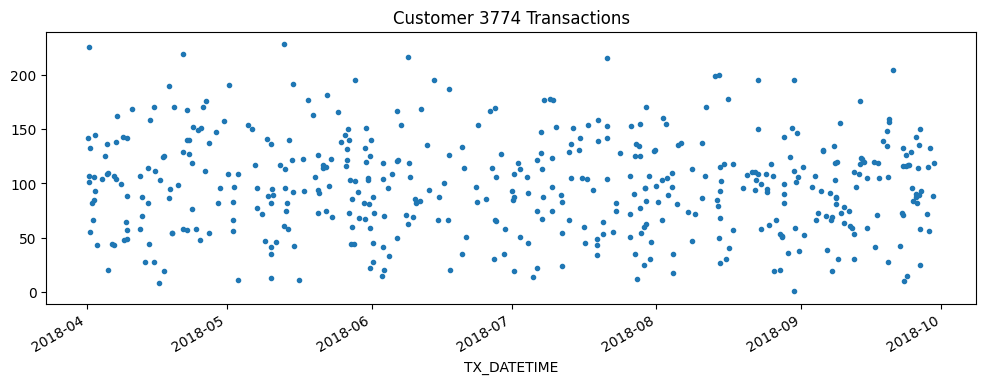

In [ ]:
df[df['CUSTOMER_ID'].astype(int) == 3774]['TX_AMOUNT'].plot(title='Customer 3774 Transactions', style='.', figsize=(12, 4))

Note the few fraudulent transactions for this client.

## Preparing the training data

Fraudulent transactions in isolation cannot be detected. Instead, we need to
connect related transactions. For each transaction, we compute the sum and count
of transactions for the same terminal in the last `n` days. Because we don't
know the correct value for `n`, we use multiple values for `n` and compute a
set of features for each of them.

In [ ]:
# Group the transactions per terminal and per customer to calculate rolling statistics
for n in [7, 14, 28]:
    # Rolling sum and count for the last n days per terminal
    df[f'sum_transactions_{n}_days'] = df.groupby('TERMINAL_ID')['TX_AMOUNT'].transform(lambda x: x.rolling(f'{n}D').sum())
    df[f'count_transactions_{n}_days'] = df.groupby('TERMINAL_ID')['TX_AMOUNT'].transform(lambda x: x.rolling(f'{n}D').count())

    # Rolling sum and count for the last n days per customer
    df[f'sum_transactions_customer_{n}_days'] = df.groupby('CUSTOMER_ID')['TX_AMOUNT'].transform(lambda x: x.rolling(f'{n}D').sum())
    df[f'count_transactions_customer_{n}_days'] = df.groupby('CUSTOMER_ID')['TX_AMOUNT'].transform(lambda x: x.rolling(f'{n}D').count())

df.head()

,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD,sum_transactions_7_days,count_transactions_7_days,sum_transactions_customer_7_days,count_transactions_customer_7_days,sum_transactions_14_days,count_transactions_14_days,sum_transactions_customer_14_days,count_transactions_customer_14_days,sum_transactions_28_days,count_transactions_28_days,sum_transactions_customer_28_days,count_transactions_customer_28_days
TX_DATETIME,,,,,,,,,,,,,,,,
2018-04-01 00:00:31,596,3156,57.16,0,57.16,1.0,57.16,1.0,57.16,1.0,57.16,1.0,57.16,1.0,57.16,1.0
2018-04-01 00:02:10,4961,3412,81.51,0,81.51,1.0,81.51,1.0,81.51,1.0,81.51,1.0,81.51,1.0,81.51,1.0
2018-04-01 00:07:56,2,1365,146.00,0,146.00,1.0,146.00,1.0,146.00,1.0,146.00,1.0,146.00,1.0,146.00,1.0
2018-04-01 00:09:29,4128,8737,64.49,0,64.49,1.0,64.49,1.0,64.49,1.0,64.49,1.0,64.49,1.0,64.49,1.0
2018-04-01 00:10:34,927,9906,50.99,0,50.99,1.0,50.99,1.0,50.99,1.0,50.99,1.0,50.99,1.0,50.99,1.0


Let's look at the features of terminal "3774".

<Axes: title={'center': 'Terminal 3774 Features'}, xlabel='TX_DATETIME'>

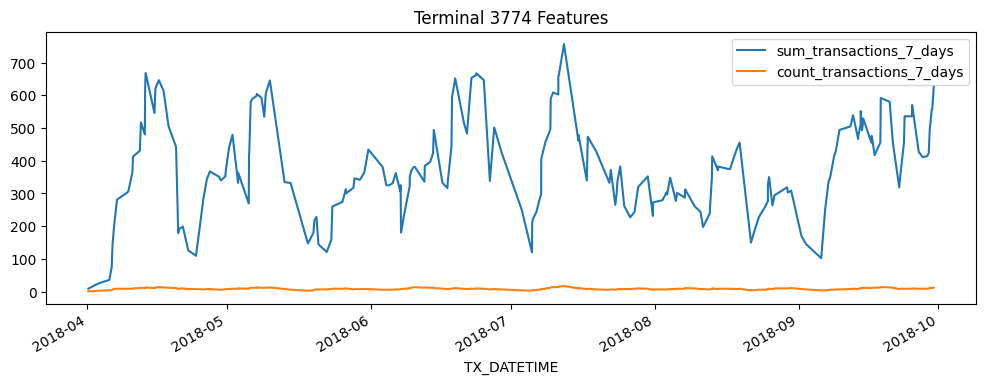

In [ ]:
df[df['TERMINAL_ID'].astype(int) == 3774][['sum_transactions_7_days', 'count_transactions_7_days']].plot(title='Terminal 3774 Features', figsize=(12, 4))

A transaction's fraudulent status is not known at the time of the transaction
(otherwise, there would be no problem). However, the banks knows if a
transacation is fraudulent one week after it is made. We create a set of
features that indicate the number and ratio of fraudulent transactions in the
last N days.

In [ ]:
# Calculate lagged fraud statistics (1 week delay) using Pandas
temp_df = df[['TERMINAL_ID', 'TX_FRAUD']].copy()
for n in [7, 14, 28]:
    temp_df[f'fraud_sum_{n}d'] = temp_df.groupby('TERMINAL_ID')['TX_FRAUD'].transform(lambda x: x.rolling(f'{n}D').sum())
    temp_df[f'fraud_count_{n}d'] = temp_df.groupby('TERMINAL_ID')['TX_FRAUD'].transform(lambda x: x.rolling(f'{n}D').count())

# Offset the index by 7 days to simulate the 1-week delay in label availability
temp_df.index = temp_df.index + pd.Timedelta(days=7)
temp_df = temp_df.sort_index().reset_index()

df = df.reset_index()
df = pd.merge_asof(df, temp_df, on='TX_DATETIME', by='TERMINAL_ID', direction='backward')
df.set_index('TX_DATETIME', inplace=True)

for n in [7, 14, 28]:
    df[f'count_fraud_transactions_{n}_days'] = df[f'fraud_sum_{n}d'].fillna(0)
    df[f'rate_fraud_transactions_{n}_days'] = (df[f'fraud_sum_{n}d'] / df[f'fraud_count_{n}d']).fillna(0)
    df.drop(columns=[f'fraud_sum_{n}d', f'fraud_count_{n}d'], inplace=True)

df[[c for c in df.columns if 'fraud_transactions' in c]].head()

,count_fraud_transactions_7_days,rate_fraud_transactions_7_days,count_fraud_transactions_14_days,rate_fraud_transactions_14_days,count_fraud_transactions_28_days,rate_fraud_transactions_28_days
TX_DATETIME,,,,,,
2018-04-01 00:00:31,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-01 00:02:10,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-01 00:07:56,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-01 00:09:29,0.0,0.0,0.0,0.0,0.0,0.0
2018-04-01 00:10:34,0.0,0.0,0.0,0.0,0.0,0.0


Transaction date and time can be correlated with fraud. While each transaction
has a timestamp, a machine learning model might struggle to consume them
directly. Instead, we extract various informative calendar features from the
timestamps, such as hour, day of the week (e.g., Monday, Tuesday), and day of
the month (1-31).

In [ ]:
# Extract calendar features natively with Pandas
df['calendar_hour'] = df.index.hour
df['calendar_day_of_week'] = df.index.dayofweek

df[['calendar_hour', 'calendar_day_of_week']].head()

,calendar_hour,calendar_day_of_week
TX_DATETIME,,
2018-04-01 00:00:31,0,6
2018-04-01 00:02:10,0,6
2018-04-01 00:07:56,0,6
2018-04-01 00:09:29,0,6
2018-04-01 00:10:34,0,6


Finally, we group together all the features and the label.

In [ ]:
print("All the available features:")
print(df.columns.tolist())

All the available features:
['CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_FRAUD_x', 'sum_transactions_7_days', 'count_transactions_7_days', 'sum_transactions_customer_7_days', 'count_transactions_customer_7_days', 'sum_transactions_14_days', 'count_transactions_14_days', 'sum_transactions_customer_14_days', 'count_transactions_customer_14_days', 'sum_transactions_28_days', 'count_transactions_28_days', 'sum_transactions_customer_28_days', 'count_transactions_customer_28_days', 'TX_FRAUD_y', 'count_fraud_transactions_7_days', 'rate_fraud_transactions_7_days', 'count_fraud_transactions_14_days', 'rate_fraud_transactions_14_days', 'count_fraud_transactions_28_days', 'rate_fraud_transactions_28_days', 'calendar_hour', 'calendar_day_of_week']


We extract the name of the input features.

In [ ]:
input_feature_names = [col for col in df.columns if col.islower()]

print("The model's input features:")
input_feature_names

The model's input features:


['sum_transactions_7_days',
 'count_transactions_7_days',
 'sum_transactions_customer_7_days',
 'count_transactions_customer_7_days',
 'sum_transactions_14_days',
 'count_transactions_14_days',
 'sum_transactions_customer_14_days',
 'count_transactions_customer_14_days',
 'sum_transactions_28_days',
 'count_transactions_28_days',
 'sum_transactions_customer_28_days',
 'count_transactions_customer_28_days',
 'count_fraud_transactions_7_days',
 'rate_fraud_transactions_7_days',
 'count_fraud_transactions_14_days',
 'rate_fraud_transactions_14_days',
 'count_fraud_transactions_28_days',
 'rate_fraud_transactions_28_days',
 'calendar_hour',
 'calendar_day_of_week']

For neural networks to work correctly, numerical inputs must be normalized. A
common approach is to apply z-normalization, which involves subtracting the mean
and dividing by the standard deviation estimated from the training data to each
value. In forecasting, such z-normalization is not recommended as it would lead
to future leakage. Specifically, to classify a transaction at time t, we cannot
rely on data after time t since, at serving time when making a prediction at
time t, no subsequent data is available yet. In short, at time t, we are limited
to using data that precedes or is concurrent with time t.

The solution is therefore to apply z-normalization **over time**, which means
that we normalize each transaction using the mean and standard deviation
computed from the past data **for that transaction**.

Future leakage is pernicious. Luckily, Temporian is here to help: the only
operator that can cause future leakage is `EventSet.leak()`. If you are not
using `EventSet.leak()`, your preprocessing is **guaranteed** not to create
future leakage.

**Note:** For advanced pipelines, you can also check programatically that a
feature does not depends on an `EventSet.leak()` operation.

In [ ]:
# Apply expanding window Z-normalization
normalized_features = pd.DataFrame(index=df.index)
for col in input_feature_names:
    expanding_mean = df[col].expanding().mean()
    expanding_std = df[col].expanding().std()
    normalized_features[col] = (df[col] - expanding_mean) / expanding_std

print(normalized_features.head())

                     sum_transactions_7_days  count_transactions_7_days  \
TX_DATETIME                                                               
2018-04-01 00:00:31                      NaN                        NaN   
2018-04-01 00:02:10                 0.707107                        NaN   
2018-04-01 00:07:56                 1.113351                        NaN   
2018-04-01 00:09:29                -0.563698                        NaN   
2018-04-01 00:10:34                -0.752190                        NaN   

                     sum_transactions_customer_7_days  \
TX_DATETIME                                             
2018-04-01 00:00:31                               NaN   
2018-04-01 00:02:10                          0.707107   
2018-04-01 00:07:56                          1.113351   
2018-04-01 00:09:29                         -0.563698   
2018-04-01 00:10:34                         -0.752190   

                     count_transactions_customer_7_days  \
TX_DATETIME    

The first transactions will be normalized using poor estimates of the mean and
standard deviation since there are only a few transactions before them. To
mitigate this issue, we remove the first week of data from the training dataset.

Notice that the first values contain NaN. In Temporian, NaN represents missing
values, and all operators handle them accordingly. For instance, when
calculating a moving average, NaN values are not included in the calculation
and do not generate a NaN result.

However, neural networks cannot natively handle NaN values. So, we replace them
with zeros.

In [ ]:
normalized_features = normalized_features.fillna(0.0)

Finally, we group together the features and the labels.

In [ ]:
normalized_all_data = df.copy()
normalized_all_data[input_feature_names] = normalized_features

## Split dataset into a train, validation and test set

To evaluate the quality of our machine learning model, we need training,
validation and test sets. Since the system is dynamic (new fraud patterns are
being created all the time), it is important for the training set to come before
the validation set, and the validation set come before the testing set:

- **Training:** April 8, 2018 to July 31, 2018
- **Validation:** August 1, 2018 to August 31, 2018
- **Testing:** September 1, 2018 to September 30, 2018

For the example to run faster, we will effectively reduce the size of the
training set to:
- **Training:** July 1, 2018 to July 31, 2018

In [ ]:
begin_train = pd.to_datetime('2018-04-08') # Full training dataset
begin_valid = pd.to_datetime('2018-08-01')
begin_test = pd.to_datetime('2018-09-01')

is_train = (normalized_all_data.index >= begin_train) & (normalized_all_data.index < begin_valid)
is_valid = (normalized_all_data.index >= begin_valid) & (normalized_all_data.index < begin_test)
is_test = normalized_all_data.index >= begin_test

`is_train`, `is_valid` and `is_test` are boolean features overtime that indicate
the limit of the tree folds. Let's plot them.

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

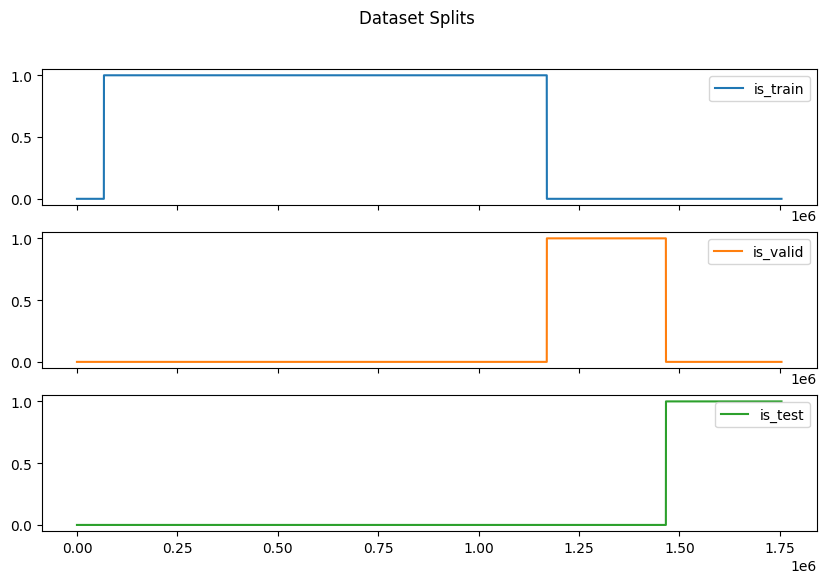

In [ ]:
pd.DataFrame({
    'is_train': is_train,
    'is_valid': is_valid,
    'is_test': is_test
}).astype(int).plot(subplots=True, figsize=(10, 6), title='Dataset Splits')

We filter the input features and label in each fold.

In [ ]:
train_df = normalized_all_data[is_train]
valid_df = normalized_all_data[is_valid]
test_df = normalized_all_data[is_test]

print(f"Training examples: {len(train_df)}")
print(f"Validation examples: {len(valid_df)}")
print(f"Testing examples: {len(test_df)}")

Training examples: 1102747
Validation examples: 296559
Testing examples: 287873


It is important to split the dataset **after** the features have been computed
because some of the features for the training dataset are computed from
transactions during the training window.

## Create TensorFlow datasets

We convert the datasets from EventSets to TensorFlow Datasets as Keras consumes
them natively.

In [ ]:
# Create unbatched tf.data.Datasets directly from Pandas DataFrames
target_col = 'TX_FRAUD_x' if 'TX_FRAUD_x' in train_df.columns else 'TX_FRAUD'

def df_to_tf_dataset(dataframe):
    features = {name: dataframe[name].values for name in input_feature_names}
    labels = dataframe[target_col].values
    return tf.data.Dataset.from_tensor_slices((features, labels))

non_batched_train_ds = df_to_tf_dataset(train_df)
non_batched_valid_ds = df_to_tf_dataset(valid_df)
non_batched_test_ds = df_to_tf_dataset(test_df)

The following processing steps are applied using TensorFlow datasets:

1. The features and labels are separated using `extract_features_and_label` in
    the format that Keras expects.
1. The dataset is batched, which means that the examples are grouped into
    mini-batches.
1. The training examples are shuffled to improve the quality of mini-batch
    training.

As we noted before, the dataset is imbalanced in the direction of legitimate
transactions. While we want to evaluate our model on this original distribution,
neural networks often train poorly on strongly imbalanced datasets. Therefore,
we resample the training dataset to a ratio of 80% legitimate / 20% fraudulent
using `rejection_resample`.

In [ ]:
# Target ratio of fraudulent transactions in the training dataset.
target_rate = 0.2
batch_size = 32

train_ds = (
    non_batched_train_ds.shuffle(10000)
    .rejection_resample(
        class_func=lambda features, label: tf.cast(label, tf.int32),
        target_dist=[1 - target_rate, target_rate],
        initial_dist=[1 - fraudulent_rate, fraudulent_rate],
    )
    .map(lambda _, data: data)  # Remove the label copy added by 'rejection_resample'.
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# The test and validation dataset does not need resampling or shuffling.
valid_ds = non_batched_valid_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = non_batched_test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

Instructions for updating:
Use tf.print instead of tf.Print. Note that tf.print returns a no-output operator that directly prints the output. Outside of defuns or eager mode, this operator will not be executed unless it is directly specified in session.run or used as a control dependency for other operators. This is only a concern in graph mode. Below is an example of how to ensure tf.print executes in graph mode:



We print the first four examples of the training dataset. This is a simple way
to identify some of the errors that could have been made above.

In [ ]:
for features, labels in train_ds.take(1):
    print("features")
    for feature_name, feature_value in features.items():
        print(f"\t{feature_name}: {feature_value[:4]}")
    print(f"labels: {labels[:4]}")

features
	sum_transactions_7_days: [1.0349649  1.31080445 2.38828641 1.84976813]
	count_transactions_7_days: [-0.24015639  2.32330165  1.39183927  2.98540309]
	sum_transactions_customer_7_days: [ 0.95582176 -0.12803527 -0.35795048 -0.26651543]
	count_transactions_customer_7_days: [-0.07572627 -0.25226995  1.63317584  0.93260643]
	sum_transactions_14_days: [1.02384038 1.27980531 2.83630434 2.12574996]
	count_transactions_14_days: [-0.24356719  2.26984204  1.69470267  3.56636509]
	sum_transactions_customer_14_days: [ 1.23293526 -0.13595648 -0.28112981 -0.15507921]
	count_transactions_customer_14_days: [ 0.0529555  -0.26091987  1.9971013   1.28747358]
	sum_transactions_28_days: [1.02384038 1.27980531 2.83630434 2.12574996]
	count_transactions_28_days: [-0.24356719  2.26984204  1.69470267  3.56636509]
	sum_transactions_customer_28_days: [ 1.23293526 -0.13595648 -0.28112981 -0.15507921]
	count_transactions_customer_28_days: [ 0.0529555  -0.26091987  1.9971013   1.28747358]
	count_fraud_tran

## Train the model

The original dataset is transactional, but the processed data is tabular and
only contains normalized numerical values. Therefore, we train a feed-forward
neural network.

In [ ]:
def build_model(hp):
    inputs = [keras.Input(shape=(1,), name=name) for name in input_feature_names]
    x = keras.layers.concatenate(inputs)

    # Tune the number of layers
    for i in range(hp.Int("num_layers", 2, 4)):
        x = keras.layers.Dense(
            units=hp.Int(f"units_{i}", min_value=16, max_value=64, step=16),
            activation=hp.Choice(f"activation_{i}", ["relu", "silu", "celu", "gelu"]),
        )(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Dropout(hp.Float(f"dropout_{i}", min_value=0.1, max_value=0.5, step=0.1))(x)

    x = keras.layers.Dense(
        1,
        activation=hp.Choice("final_activation", ["sigmoid", "softmax", "squareplus", "tanh"])
    )(x)

    model = keras.Model(inputs=inputs, outputs=x)

    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.Accuracy(), keras.metrics.AUC(name='auc')],
    )
    return model

tuner = keras_tuner.RandomSearch(
    build_model,
    objective=keras_tuner.Objective("val_auc", direction="max"),
    max_trials=25,
    executions_per_trial=1,
    directory="fraud_detection",
    project_name="fraud_detection",
    overwrite=True
)
tuner.search_space_summary()

Search space summary
Default search space size: 9
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
activation_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'celu', 'gelu'], 'ordered': False}
dropout_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
activation_1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'silu', 'celu', 'gelu'], 'ordered': False}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
final_activation (Choice)
{'default': 'sigmoid', 'conditions': [], 'values': ['sigmoid', 'softmax', 'squ

Our goal is to differentiate between the fraudulent and legitimate transactions,
so we use a binary classification objective. Because the dataset is imbalanced,
accuracy is not an informative metric. Instead, we evaluate the model using the
[area under the curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic#Area_under_the_curve)
(AUC).

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
)

print("Searching for the best hyperparameters...")
tuner.search(
    train_ds,
    epochs=25,  # Fewer epochs just for the search phase
    validation_data=valid_ds,
    callbacks=[early_stopping]
)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

print("\nTraining the best model for up to 100 epochs...")
history = best_model.fit(
    train_ds,
    epochs=100,
    validation_data=valid_ds
)

# Override `model` with `best_model` so downstream evaluation cells continue to work
model = best_model

Searching for the best hyperparameters...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(store)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sum_transactions_7… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_transactions… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_transactions_c… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_transactions… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_transactions_1… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_transactions… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_transactions_c… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_transactions… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_transactions_2… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_transactions… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_transactions_c… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_transactions… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_fraud_transa… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rate_fraud_transac… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_fraud_transa… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rate_fraud_transac… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ count_fraud_transa… │ (None, 1)         │          0 │ -               

 Total params: 10,497 (41.00 KB)

 Trainable params: 10,081 (39.38 KB)

 Non-trainable params: 416 (1.62 KB)


Training the best model for up to 100 epochs...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1521/1521 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.0000e+00 - auc: 0.9702 - loss: 0.2479 - val_accuracy: 0.0000e+00 - val_auc: 0.5817 - val_loss: 11.2172
Epoch 2/100
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 76s 50ms/step - accuracy: 0.0000e+00 - auc: 0.9762 - loss: 0.2222 - val_accuracy: 0.0000e+00 - val_auc: 0.5760 - val_loss: 11.9657
Epoch 3/100
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 75s 49ms/step - accuracy: 0.0000e+00 - auc: 0.9792 - loss: 0.2015 - val_accuracy: 0.0000e+00 - val_auc: 0.5188 - val_loss: 14.7348
Epoch 4/100
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 73s 48ms/step - accuracy: 0.0000e+00 - auc: 0.9863 - loss: 0.1380 - val_accuracy: 0.0000e+00 - val_auc: 0.5065 - val_loss: 15.4463
Epoch 5/100
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 72s 47ms/step - accuracy: 0.0000e+00 - auc: 0.9874 - loss: 0.1160 - val_accuracy: 0.0000e+00 - val_auc: 0.5030 - val_loss: 15.6281
Epoch 6/100
1521/1521 ━━━━━━━━━━━━━━━━━━━━ 73s 48ms/step - accuracy: 0.0000e+00 - auc: 0.9882 - loss: 0.0936 - val_accuracy: 0.0000e+00 - val_

We evaluate the model on the test dataset.

In [ ]:
model.evaluate(test_ds)

8997/8997 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.0000e+00 - auc: 0.5003 - loss: 15.7937


[15.793655395507812, 0.0, 0.5002716183662415]

Compared to an AUC of ~83% in the original work, our tuned neural network fraud detector is showing much poorer results.


Plotting the ROC curve is a good solution to understand and select the operation
point of the model i.e. the threshold applied on the model output to
differentiate between fraudulent and legitimate transactions.

Compute the test predictions:

In [ ]:
predictions = model.predict(test_ds)
predictions = np.nan_to_num(predictions, nan=0)

Extract the labels from the test set:

In [ ]:
labels = np.concatenate([label for _, label in test_ds])

Finaly, we plot the ROC curve.

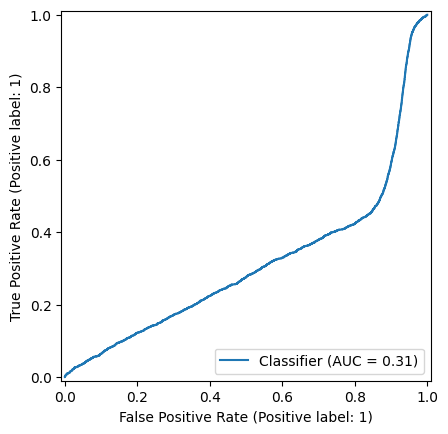

In [ ]:
_ = RocCurveDisplay.from_predictions(labels, predictions)


Because the dataset is highly imbalanced, the ROC curve can sometimes be misleadingly optimistic. A Precision-Recall curve and the Area Under the PR Curve (AUPRC, or Average Precision) are often much more informative for fraud detection.

Area Under the Precision-Recall Curve (AUPRC): 0.0071


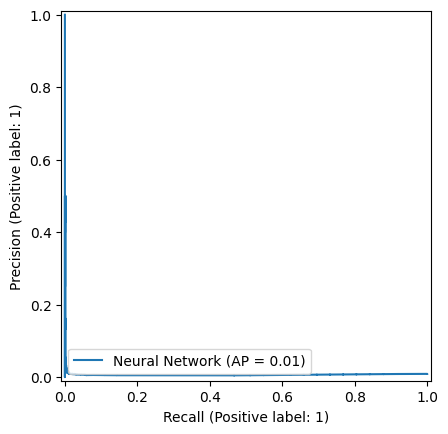

In [37]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

# Calculate the Average Precision (AUPRC)
auprc = average_precision_score(labels, predictions)
print(f"Area Under the Precision-Recall Curve (AUPRC): {auprc:.4f}")

# Plot the Precision-Recall curve
_ = PrecisionRecallDisplay.from_predictions(labels, predictions, name="Neural Network")

The Keras model is ready to be used on transactions with an unknown fraud
status, a.k.a. serving. We save the model on disk for future use.

**Note:** The model does not include the data preparation and preprocessing steps
done in Pandas and Temporian. They have to be applied manually to the data fed
into the model. While not demonstrated here, Temporian preprocessing can also be
saved to disk with
[tp.save](https://temporian.readthedocs.io/en/latest/reference/temporian/serialization/save/).

In [ ]:
model.save("fraud_detection_model.keras")

The model can be later reloaded with:

In [ ]:
loaded_model = keras.saving.load_model("fraud_detection_model.keras")

# Generate predictions with the loaded model on 5 test examples.
loaded_model.predict(test_ds.rebatch(5).take(1))

## Tree-Based Models Comparison

Tree-based models like XGBoost, LightGBM, and CatBoost are known to perform exceptionally well on tabular data and handle imbalanced datasets efficiently. We will train these models and compare them against our Neural Network.

In [38]:
!pip install -q catboost xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 163.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 19.0 MB/s eta 0:00:00


In [39]:
# Prepare the data for tree-based models (they expect standard arrays/dataframes, not tf.data.Dataset)
X_train = train_df[input_feature_names]
y_train = train_df[target_col]

X_valid = valid_df[input_feature_names]
y_valid = valid_df[target_col]

X_test = test_df[input_feature_names]
y_test = test_df[target_col]

In [40]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("Training XGBoost...")
xgb_model = XGBClassifier(eval_metric='auc', random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

print("Training LightGBM...")
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)])

print("Training CatBoost...")
cat_model = CatBoostClassifier(eval_metric='AUC', random_state=42, verbose=False)
cat_model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

print("All models trained successfully!")

Training XGBoost...
Training LightGBM...


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 9328, number of negative: 1093419
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 1102747, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.008459 -> initscore=-4.764044
[LightGBM] [Info] Start training from score -4.764044
Training CatBoost...
All models trained successfully!


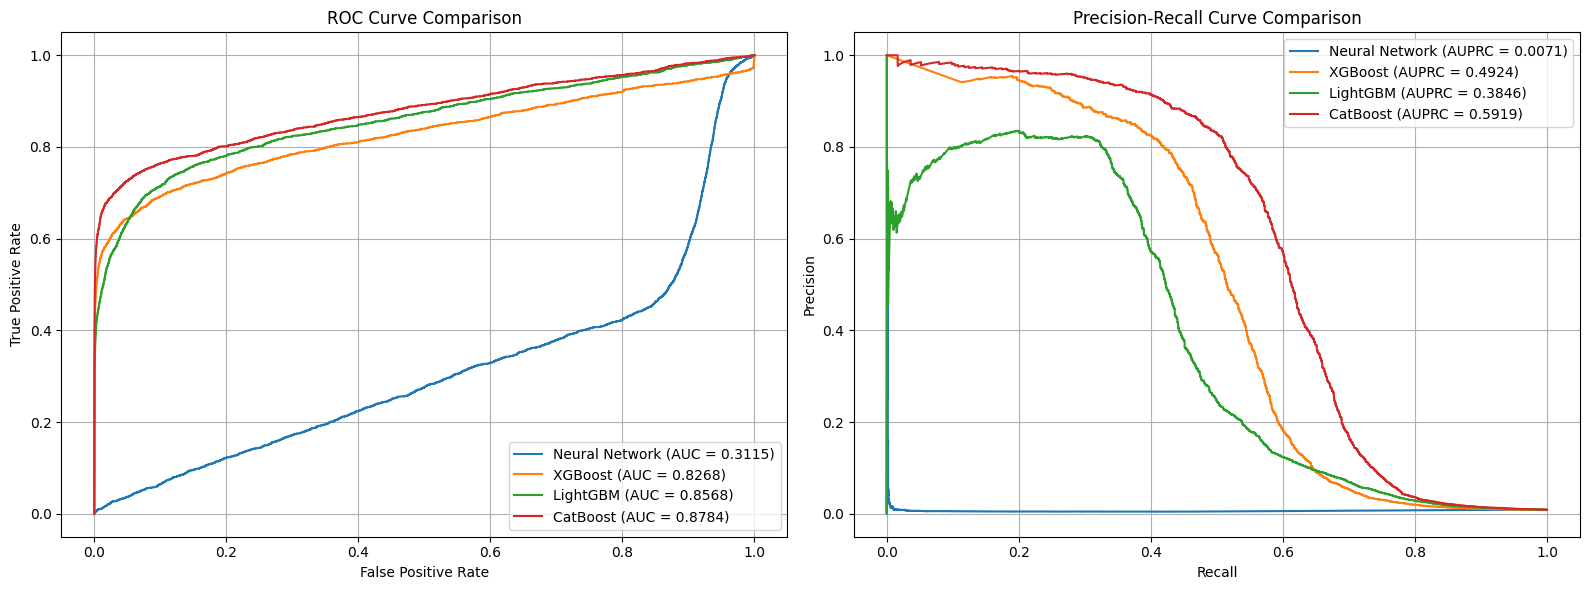

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Get probability predictions for the positive class (fraud)
xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
lgb_preds = lgb_model.predict_proba(X_test)[:, 1]
cat_preds = cat_model.predict_proba(X_test)[:, 1]

# Group all predictions together (including the NN predictions from earlier)
all_preds = {
    'Neural Network': predictions.flatten(),
    'XGBoost': xgb_preds,
    'LightGBM': lgb_preds,
    'CatBoost': cat_preds
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, preds in all_preds.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, preds)
    pr_auc = average_precision_score(y_test, preds)
    ax2.plot(recall, precision, label=f'{name} (AUPRC = {pr_auc:.4f})')

# Formatting ROC plot
ax1.set_title('ROC Curve Comparison')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True)

# Formatting PR plot
ax2.set_title('Precision-Recall Curve Comparison')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()